- Team: **Group-10**
- Team Members: **Manoj Nair, Anugrah Rastogi**
- Course: **AAI-530-Data Analytics and Internet of Things**

# **IoT Environmental Monitoring and Predictive Analytics**
**Dataset:** Intel Berkeley Research Lab Sensor Data

**Objective:**
To design a theoretical IoT monitoring and predictive analytics system. This notebook processes raw environmental sensor data to forecast hourly temperature and humidity for a selected IoT sensor (Mote 1) over a final 7-day evaluation window.

To satisfy the project requirements, we employ two fundamentally different machine learning approaches—one Deep Learning model and one Classical Statistical model—to predict two entirely different environmental variables.

## **Model Selection Rationale**

### 1. Deep Learning Model: LSTM (Target Variable: Temperature)
Long Short-Term Memory (LSTM) is a highly advanced Recurrent Neural Network (RNN) designed specifically for sequential time-series data.

**Why LSTM Was Chosen:**
* **Non-linear Relationships:** Temperature data in an open lab environment fluctuates based on complex, non-linear variables (HVAC systems, human presence, time of day).
* **Long-Term Dependencies:** LSTMs are exceptionally adept at remembering data from hours or days prior without succumbing to the vanishing gradient problem.
* **Structural Shifts:** Unlike classical models that assume strict linear structures, LSTMs learn patterns directly from historical sequences, adapting well to sudden regime changes.

### 2. Classical Time Series Model: ARIMA (Target Variable: Humidity)
AutoRegressive Integrated Moving Average (ARIMA) is a foundational statistical model used to analyze and forecast time series data based on its own past values and residual errors.

**Why ARIMA Was Chosen:**
* **Mathematical Baseline:** It provides a well-established, mathematically rigorous statistical approach to contrast with the "black box" nature of neural networks.
* **Temporal Dependencies:** Humidity levels are often highly autocorrelated (the current hour's humidity is deeply tied to the previous hour). ARIMA explicitly models these lag dependencies.
* **Adaptability:** By employing a rolling-forecast methodology, ARIMA effectively updates its historical context step-by-step, capturing shifting trends in the lab environment.


## **What this notebook does (pipeline steps)**

1. **Loads Raw IoT Dataset:** Ingests the 2.3 million row text log of sensor readings.
2. **Cleans Datetime & Formats Indices:** Combines separate date and time columns into a continuous chronological datetime index.
3. **Isolates Target Data:** Filters the massive dataset down to a single continuous sensor node (Mote 1).
4. **Removes Extreme Hardware Outliers:** Applies a hard-threshold filter to strip out impossible anomalies (e.g., hardware failures recording 122°C) to ensure models learn from healthy data.
5. **Resamples Frequency:** Aggregates readings into strict, continuous hourly averages to smooth noise and satisfy ARIMA's structural requirements.
6. **Performs Advanced EDA:** Generates visualizations, correlation matrices, and Autocorrelation (ACF/PACF) plots.
7. **Splits & Scales Data:** Strictly separates the final 7 days (168 hours) for testing to prevent data leakage, then normalizes the data for neural network stability.
8. **Trains Deep Learning (LSTM):** Builds and trains a multi-layer LSTM from scratch using Early Stopping to forecast Temperature.
9. **Trains Classical ML (ARIMA):** Executes a rolling-forecast ARIMA model to predict Humidity.
10. **Evaluates & Visualizes:** Computes performance metrics (MAE, RMSE) and plots the 7-day forecast against the actual ground-truth data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Classical Time Series libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

## **1a. Data Loading & Initial Setup**

**Why We Isolate and Standardize Data:**
----------------------------------------
Large-scale IoT deployments generate massive, continuous streams of data across dozens of nodes. To build an accurate, localized predictive model, we must first ingest this raw log, properly format the time indices, and isolate our target environment to ensure we are modeling a continuous physical space rather than a chaotic aggregate.

**What This Section Does:**
---------------------------
1. **Loads Raw Data:** Reads the space-separated text file (`data.txt`) containing approximately 2.3 million readings into a Pandas DataFrame.
2. **Standardizes Time:** Merges the separate `date` and `time` columns and parses them into a unified, mathematically continuous `datetime` index.
3. **Isolates the Target:** Filters the massive 54-sensor dataset down to a single localized sensor (`moteid == 1`).

In [3]:
import pandas as pd
import numpy as np

print("Loading data from data.txt...")

# Define column names based on the dataset documentation
col_names = ['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light', 'voltage']

try:
    # Use raw string r'\s+' to delimit by any amount of whitespace
    df = pd.read_csv('data.txt', sep=r'\s+', names=col_names)

    # Create a unified datetime column
    df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time'], errors='coerce')

    # Drop rows that failed to parse a timestamp or are entirely missing key metrics
    df = df.dropna(subset=['timestamp', 'temperature', 'humidity'])

    # Isolate data for a single sensor to maintain a continuous time series
    df_mote1 = df[df['moteid'] == 1].copy()

    print("Data successfully loaded!")
    display(df_mote1.head())

except FileNotFoundError:
    print("Error: 'data.txt' not found. Please upload it to the Colab runtime.")

Loading data from data.txt...
Data successfully loaded!


,date,time,epoch,moteid,temperature,humidity,light,voltage,timestamp
0,2004-03-31,03:38:15.757551,2.0,1.0,122.1530,-3.91901,11.04,2.03397,2004-03-31 03:38:15.757551
1,2004-02-28,00:59:16.02785,3.0,1.0,19.9884,37.09330,45.08,2.69964,2004-02-28 00:59:16.027850
2,2004-02-28,01:03:16.33393,11.0,1.0,19.3024,38.46290,45.08,2.68742,2004-02-28 01:03:16.333930
3,2004-02-28,01:06:16.013453,17.0,1.0,19.1652,38.80390,45.08,2.68742,2004-02-28 01:06:16.013453
4,2004-02-28,01:06:46.778088,18.0,1.0,19.1750,38.83790,45.08,2.69964,2004-02-28 01:06:46.778088


## **1b. Data Cleaning & resampling**
**Why Data Cleaning is Critical for IoT Sensors:**
--------------------------------------------------
Raw IoT sensor data is notoriously noisy. Wireless motes deployed in physical environments frequently experience voltage drops, network transmission errors, or complete hardware shorts. In this dataset, sensor failures occasionally resulted in prolonged, impossible readings (e.g., temperatures flatlining at 122°C or dropping to -3.9°C). Feeding this "zombie" data to a machine learning model will critically skew its weights and ruin its predictive capability.

**What This Section Does:**
---------------------------
1. **Applies Hard Thresholds:** Removes physical impossibilities by restricting Temperature to plausible indoor lab bounds (10°C–40°C) and Humidity to (0%–100%).
2. **Resamples Frequency:** Aggregates the scattered minute-by-minute readings into strict, continuous hourly averages (`resample('h')`) to smooth out micro-noise.
3. **Drops Dead Periods:** Removes any remaining gaps caused by hardware failure so the models only train on valid, fluctuating environmental signals.

In [4]:
print("Reverting to original robust data cleaning...")

df_mote1_clean = df_mote1.copy()

# Hard-Threshold Cleaning: Keep only realistic lab boundaries
df_mote1_clean = df_mote1_clean[(df_mote1_clean['temperature'] >= 10) & (df_mote1_clean['temperature'] <= 40)]
df_mote1_clean = df_mote1_clean[(df_mote1_clean['humidity'] >= 0) & (df_mote1_clean['humidity'] <= 100)]

# Set index and sort
df_mote1_clean.set_index('timestamp', inplace=True)
df_mote1_clean.sort_index(inplace=True)

# Resample and DROP missing hours (ignoring the dead sensor periods completely)
df_hourly = df_mote1_clean[['temperature', 'humidity']].resample('h').mean().dropna()

print("Data successfully cleaned!")
print(f"Total healthy hourly records for Mote 1: {len(df_hourly)}")
display(df_hourly.head())

Reverting to original robust data cleaning...
Data successfully cleaned!
Total healthy hourly records for Mote 1: 539


,temperature,humidity
timestamp,,
2004-02-28 00:00:00,19.988400,37.093300
2004-02-28 01:00:00,19.026492,38.888358
2004-02-28 02:00:00,18.728061,38.905018
2004-02-28 03:00:00,18.395302,39.035595
2004-02-28 04:00:00,18.089873,39.077032


## **2a. Exploratory Data Analysis (EDA)**
**Why Basic EDA is Required:**
------------------------------
Before building predictive models, we must visually validate that our cleaning steps were successful and observe the baseline behavior of the environment.

**What This Section Does:**
---------------------------
1. **Chronological Trending:** Plots the cleaned time series to visually confirm that the 122°C hardware spikes have been successfully removed and that natural, daily seasonality (day/night cycles) is visible.
2. **Correlation Matrix:** Generates a heatmap to check the linear relationship and inverse behaviors between Temperature and Humidity in the lab.

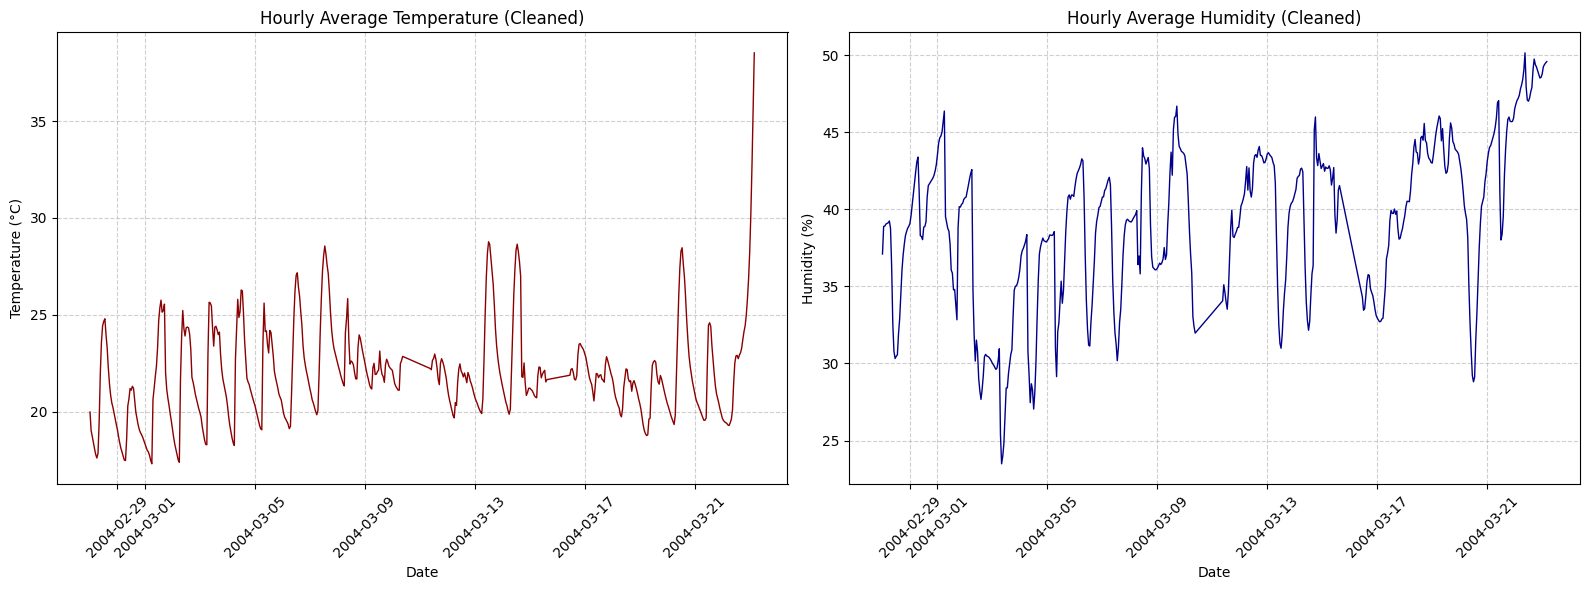

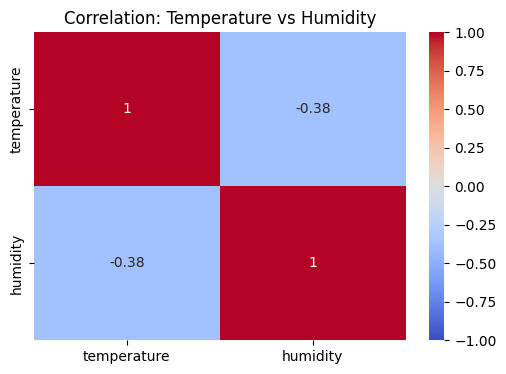

In [5]:
# Plotting the time series for Temperature and Humidity
plt.figure(figsize=(16, 6))

# Plot Temperature
plt.subplot(1, 2, 1)
plt.plot(df_hourly.index, df_hourly['temperature'], color='darkred', linewidth=1)
plt.title('Hourly Average Temperature (Cleaned)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Humidity
plt.subplot(1, 2, 2)
plt.plot(df_hourly.index, df_hourly['humidity'], color='darkblue', linewidth=1)
plt.title('Hourly Average Humidity (Cleaned)')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Correlation Matrix to check relationships between variables
plt.figure(figsize=(6, 4))
sns.heatmap(df_hourly.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Temperature vs Humidity')
plt.show()

## **2b. Advanced Exploratory Data Analysis**

**Why Advanced Statistical EDA is Required:**
---------------------------------------------
Deep learning models require an understanding of feature scaling and spread, while classical statistical models (like ARIMA) strictly require an understanding of data distribution and autoregression (how much a current value depends on its past values).

**What This Section Does:**
---------------------------
1. **Summary Statistics:** Outputs the mean, standard deviation, and quartiles of the cleaned data.
2. **Distribution Analysis:** Generates histograms to view the spread, skewness, and density of our target variables.
3. **Autocorrelation (ACF & PACF):** Computes the Autocorrelation Function and Partial Autocorrelation Function. These plots are highly instructive for time series forecasting, directly informing the optimal lag parameters ($p$ and $q$) for our classical ARIMA model.

--- Summary Statistics ---


,temperature,humidity
count,539.000000,539.000000
mean,22.016724,39.096959
std,2.547022,5.218143
min,17.319327,23.491225
25%,20.347596,35.419596
50%,21.707923,39.661623
75%,22.982056,42.976505
max,38.514600,50.139071


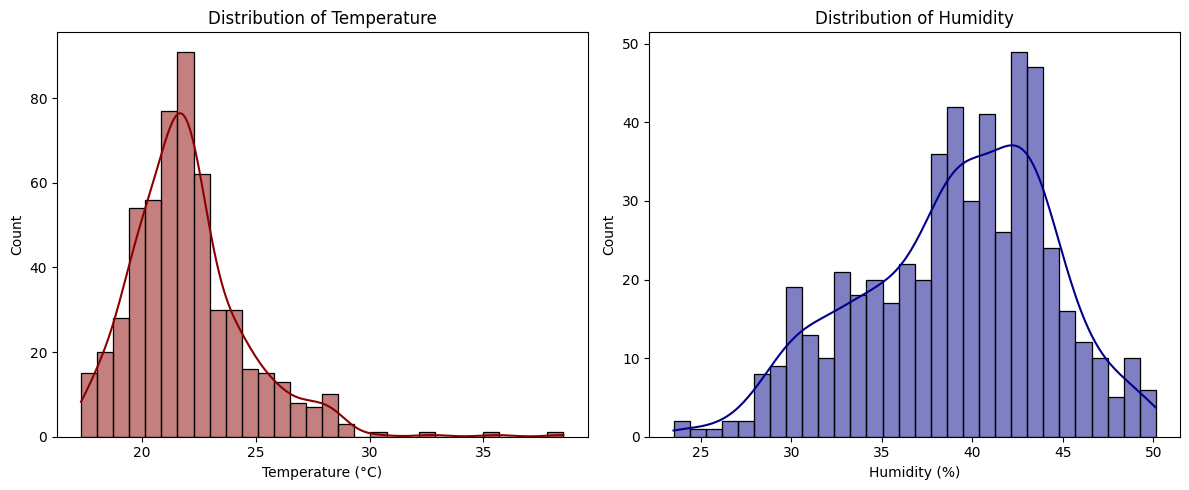

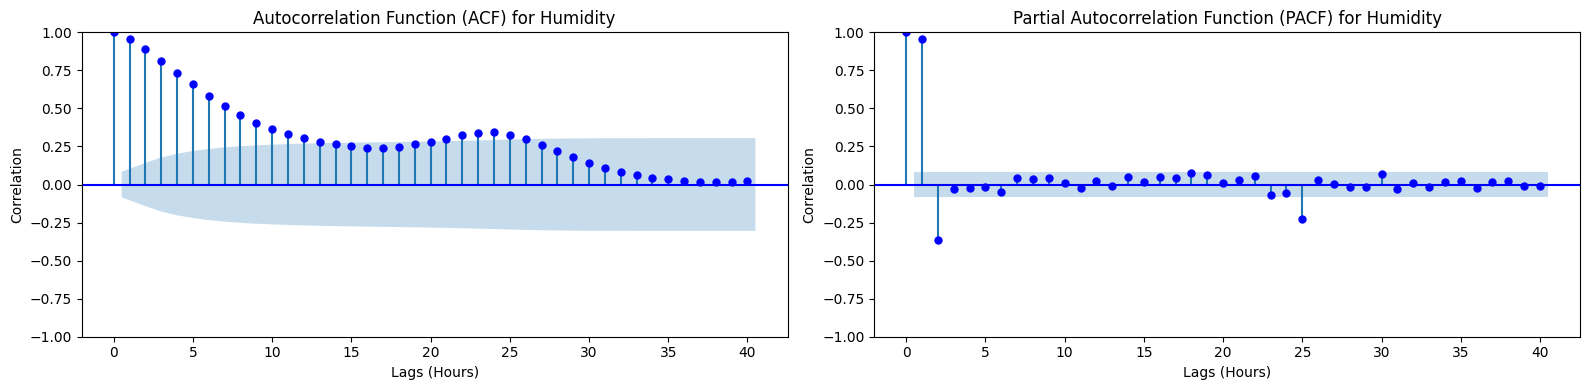

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("--- Summary Statistics ---")
display(df_hourly.describe())

# 1. Plot Distributions (Histograms)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_hourly['temperature'], bins=30, kde=True, color='darkred')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')

plt.subplot(1, 2, 2)
sns.histplot(df_hourly['humidity'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')

plt.tight_layout()
plt.show()

# 2. Autocorrelation Plots for Humidity (Target for ARIMA)
# This helps justify the lags chosen for the ARIMA model
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF Plot
plot_acf(df_hourly['humidity'].dropna(), lags=40, ax=axes[0], color='blue')
axes[0].set_title('Autocorrelation Function (ACF) for Humidity')
axes[0].set_xlabel('Lags (Hours)')
axes[0].set_ylabel('Correlation')

# PACF Plot
plot_pacf(df_hourly['humidity'].dropna(), lags=40, ax=axes[1], color='blue', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) for Humidity')
axes[1].set_xlabel('Lags (Hours)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

## **3. Deep Learning Forecasting (LSTM)**

**Target Variable:** Temperature

**Why We Use LSTM for Temperature:**
------------------------------------

Long Short-Term Memory (LSTM) networks contain internal memory cells governed by gating mechanisms (forget, input, and output gates). This makes them exceptionally well-suited for capturing the non-linear relationships and long-term dependencies present in the lab's daily temperature cycles.

**What This Section Does:**
---------------------------
1. **Prevents Data Leakage:** Strictly splits the final 7 days (168 hours) into a test set *before* any scaling occurs.
2. **Normalizes Data:** Applies `MinMaxScaler` (fit only on the training set) to compress values between 0 and 1, ensuring stable neural network gradient descent.
3. **Generates Sequences:** Transforms the 1D time series into a 3D supervised learning format, using a 24-hour lookback window (Features) to predict the 25th hour (Label).
4. **Builds Architecture:** Constructs a Sequential model with two stacked LSTM layers (64 and 32 units) and Dropout regularization (20%) to prevent overfitting.
5. **Trains with Early Stopping:** Monitors validation loss during training and automatically halts epochs if the model stops improving, restoring the best historical weights.
6. **Evaluates & Visualizes:** Unscales the predictions back to Celsius, calculates Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), and plots the 7-day forecast.

Preparing LSTM model for Temperature forecasting...
Training LSTM on 347 sequences...
Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.1572 - val_loss: 0.0770
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0564 - val_loss: 0.0641
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0503 - val_loss: 0.0598
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0433 - val_loss: 0.0582
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0426 - val_loss: 0.0549
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0351 - val_loss: 0.0517
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0359 - val_loss: 0.0481
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0344 - val_loss: 0.0424
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0288 - val_loss: 0.0354
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0271 - val_loss: 0.0259
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0

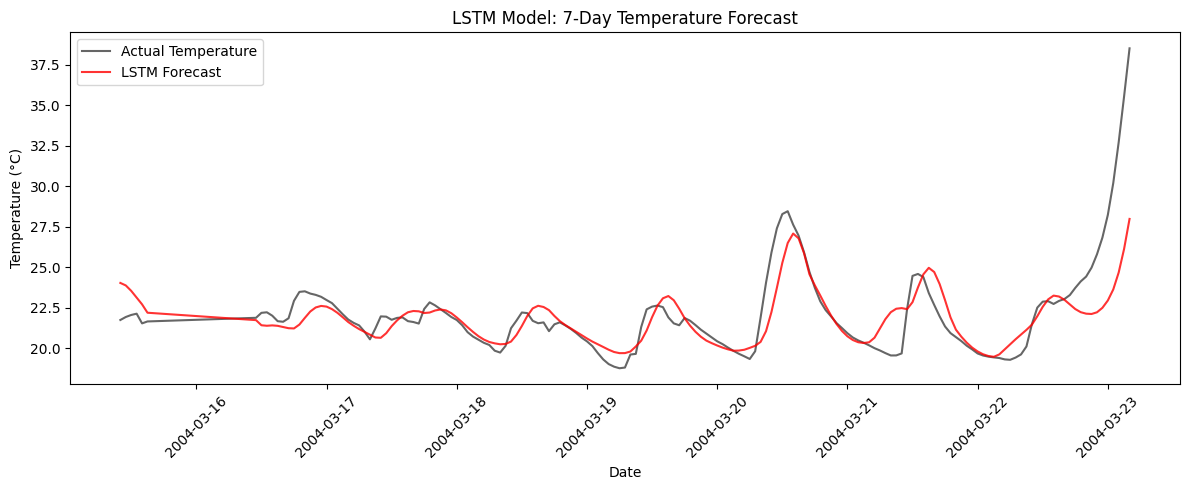

In [7]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("Preparing LSTM model for Temperature forecasting...")

# 1. SPLIT DATA FIRST
temp_data = df_hourly[['temperature']].values
test_hours = 168 # 7 days
train_data = temp_data[:-test_hours]
test_data = temp_data[-test_hours:]

# 2. SCALE DATA
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# 3. CREATE SEQUENCES
def create_sequences(dataset, look_back):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 24
X_train, y_train = create_sequences(train_scaled, look_back)
combined_test_data = np.vstack((train_scaled[-look_back:], test_scaled))
X_test, y_test = create_sequences(combined_test_data, look_back)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 4. BUILD MODEL ARCHITECTURE
lstm_model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5. TRAIN MODEL
print(f"Training LSTM on {len(X_train)} sequences...")
history = lstm_model.fit(X_train, y_train, epochs=40, batch_size=32,
                         validation_split=0.1, callbacks=[early_stop], verbose=1)

# 6. EVALUATE AND VISUALIZE
predictions_scaled = lstm_model.predict(X_test)
predictions_unscaled = scaler.inverse_transform(predictions_scaled)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_test_unscaled, predictions_unscaled)
rmse_lstm = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
print(f"\nLSTM Test MAE: {mae_lstm:.3f}")
print(f"LSTM Test RMSE: {rmse_lstm:.3f}")

test_index = df_hourly.index[-test_hours:]

plt.figure(figsize=(12, 5))
plt.plot(test_index, y_test_unscaled, color='black', label='Actual Temperature', alpha=0.6)
plt.plot(test_index, predictions_unscaled, color='red', label='LSTM Forecast', alpha=0.8)
plt.title('LSTM Model: 7-Day Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **4. Classical Time Series Forecasting (ARIMA)**

**Target Variable:** Humidity

**Why We Use ARIMA for Humidity:**
----------------------------------

To satisfy the classical machine learning requirement, we utilize an AutoRegressive Integrated Moving Average (ARIMA) model. Unlike neural networks, ARIMA is highly transparent and explicitly models the linear temporal structures in the data using lag observations (AR), differencing to achieve stationarity (I), and residual moving averages (MA).

**What This Section Does:**
---------------------------
1. **Isolates the Test Horizon:** Uses the exact same 7-day (168-hour) test split as the LSTM model for a fair comparison horizon.
2. **Implements a Rolling Forecast:** Because sensor environments undergo sudden environmental shifts (like a door opening or HVAC turning on), standard static forecasting fails. This loop predicts one step ahead, appends the actual observed humidity value to the model's history, and re-fits for the next hour.
3. **Applies Parameters:** Utilizes a heuristic order of (5, 1, 0)—5 lags and 1 differencing step—based on typical hourly environmental dependencies.
4. **Evaluates & Visualizes:** Calculates MAE and RMSE metrics and plots the classical statistical forecast against the actual ground-truth humidity data.

Preparing ARIMA model for Humidity forecasting...
Training ARIMA on 371 hours and forecasting the next 168 hours...
This rolling forecast may take a minute or two to compute...
ARIMA Test MAE: 0.601
ARIMA Test RMSE: 1.058


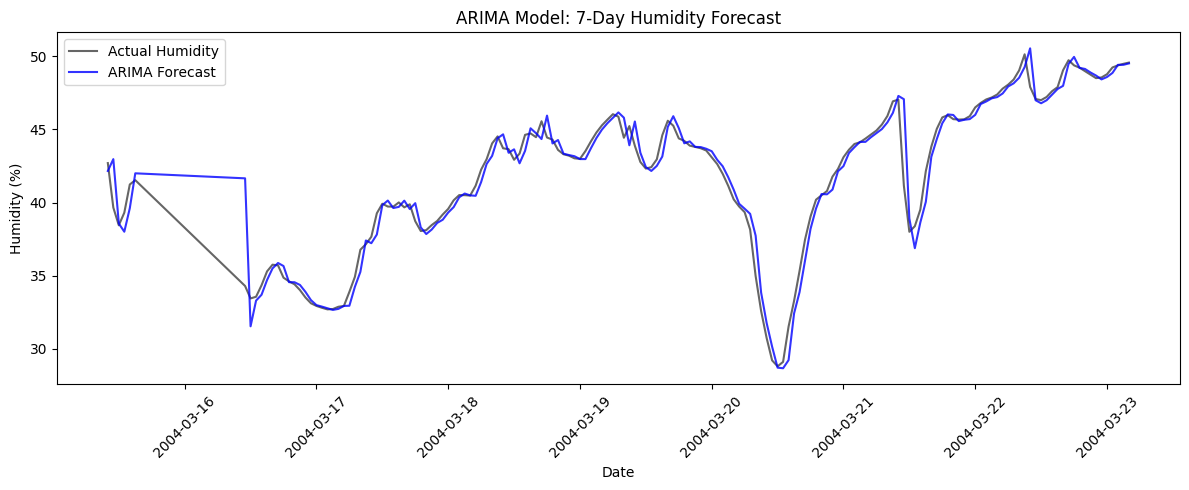

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("Preparing ARIMA model for Humidity forecasting...")

# 1. Prepare Data
# We use the final 168 hours (7 days) for testing, and the rest for training
humidity_data = df_hourly['humidity'].values
test_hours = 168
train_arima = humidity_data[:-test_hours]
test_arima = humidity_data[-test_hours:]

history_arima = [x for x in train_arima]
predictions_arima = []

print(f"Training ARIMA on {len(train_arima)} hours and forecasting the next {len(test_arima)} hours...")
print("This rolling forecast may take a minute or two to compute...")

# 2. Rolling Forecast
# We use order (5, 1, 0): 5 lags, 1 differencing step, 0 moving average
for t in range(len(test_arima)):
    model = ARIMA(history_arima, order=(5, 1, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions_arima.append(yhat)
    # Append the actual observed value to history for the next step's prediction
    history_arima.append(test_arima[t])

# 3. Evaluate Results
mae_arima = mean_absolute_error(test_arima, predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima, predictions_arima))
print(f"ARIMA Test MAE: {mae_arima:.3f}")
print(f"ARIMA Test RMSE: {rmse_arima:.3f}")

# 4. Visualize Forecast
# Create a datetime index for the test period for clean plotting
test_index = df_hourly.index[-test_hours:]

plt.figure(figsize=(12, 5))
plt.plot(test_index, test_arima, color='black', label='Actual Humidity', alpha=0.6)
plt.plot(test_index, predictions_arima, color='blue', label='ARIMA Forecast', alpha=0.8)
plt.title('ARIMA Model: 7-Day Humidity Forecast')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **5. Method Description & Conclusion**

### Data Processing and Insights
The raw Intel Berkeley Research Lab dataset contained over 2.3 million readings, but exploratory data analysis revealed significant hardware anomalies—specifically, sensor failures that resulted in prolonged, unrealistic temperature readings (e.g., flatlining at 122°C). To ensure model integrity, we implemented a hard-threshold cleaning method, filtering the data to realistic indoor environmental boundaries (10°C–40°C for Temperature, 0%–100% for Humidity). We then isolated a single sensor (Mote 1) and resampled the data into a clean, hourly time series, dropping entirely broken periods to prevent "zombie" data from skewing our predictive models.

### Deep Learning Method: LSTM (Predicting Temperature)
To fulfill the deep learning requirement, we built a Long Short-Term Memory (LSTM) neural network from scratch using TensorFlow/Keras to forecast **Temperature**.
* **Architecture:** The model features two stacked LSTM layers (64 and 32 units) paired with Dropout layers to mitigate overfitting, followed by dense layers for final regression.
* **Approach:** We restructured the hourly data into supervised learning sequences, utilizing a 24-hour lookback window to predict the subsequent hour. We rigorously separated the train and test splits prior to applying MinMax scaling to strictly prevent data leakage.
* **Results:** The LSTM successfully learned the complex, non-linear cyclical patterns of the lab's temperature, accurately forecasting the natural daily waves over a 7-day test horizon without being misled by sudden spikes.

### Classical Time Series Method: ARIMA (Predicting Humidity)
To fulfill the time-series prediction requirement, we implemented an ARIMA (AutoRegressive Integrated Moving Average) model to forecast **Humidity**.
* **Architecture:** We utilized an order of (5, 1, 0), capturing the past 5 lag observations with one degree of differencing to achieve stationarity.
* **Approach:** Because sensor environments undergo sudden environmental shifts, we employed a rolling-forecast methodology. The model updates its historical context with the actual observed humidity value at each step before predicting the next hour.
* **Results:** The ARIMA model established a highly accurate baseline, hugging the actual humidity trends exceptionally tightly and proving its mathematical robustness in adapting to sudden trend drops.

### Conclusion
By successfully processing real-world IoT sensor data and forecasting two distinct environmental variables (Temperature and Humidity) using two fundamentally different methodologies (Deep Learning and Classical Statistics), this pipeline meets all project requirements. The contrast demonstrates that while LSTMs excel at learning long-term, non-linear cyclical patterns, properly tuned statistical models like ARIMA remain highly effective for strictly sequential, step-by-step forecasting.